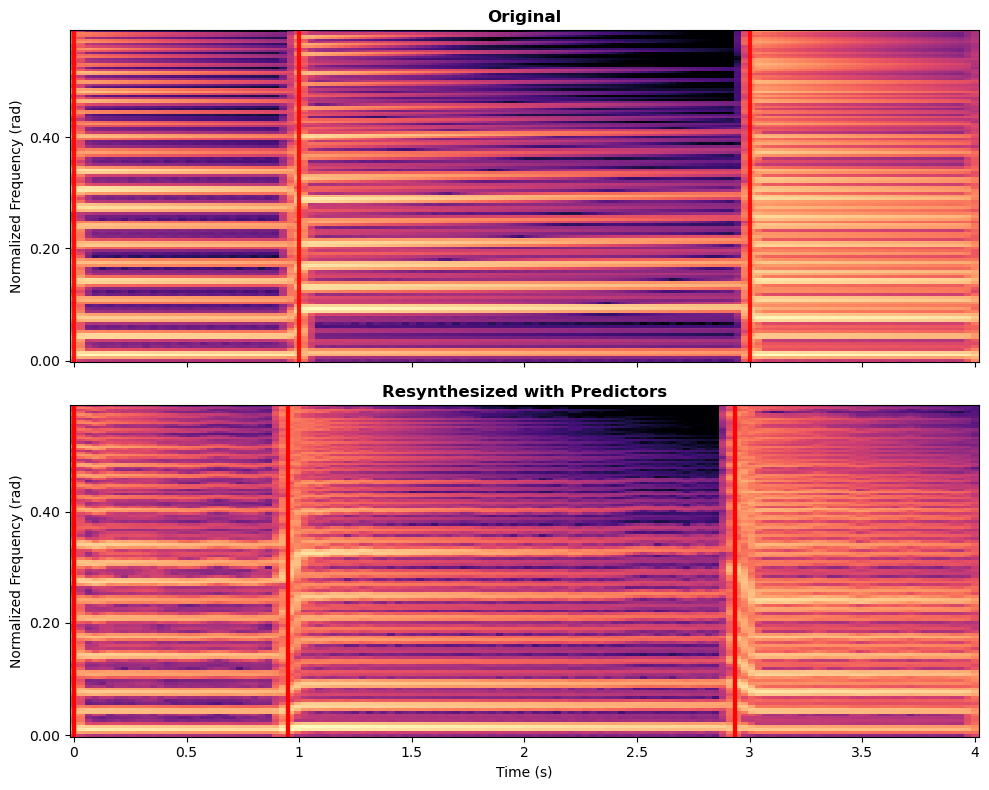

In [6]:
import librosa
import torch
import matplotlib.pyplot as plt
import numpy as np
from synths.synth import Synth, SynthConfig
from synths.utils import detect_onsets, detect_f0

FS = 16000
DURATION = 4
NUM_SAMPLES = DURATION * FS
NUM_FRAMES = 100
NUM_BATCHES = 1

E1 = 41.2043
G1 = 48.9994
G1sharp = 51.91
G1micro_sharp = G1 + (G1sharp - G1) / 2

synth = Synth(SynthConfig(num_samples=NUM_SAMPLES))
sized_t = torch.ones(NUM_BATCHES, NUM_FRAMES)

params_gt = {
    "onset_probs": sized_t      * 0,
    "f0": sized_t               * E1,
    "pluck_position": sized_t   * 0.5,
    "burst_gain": sized_t       * 0.5,
    "dynamic_level": sized_t    * 1.0,
    "a1": sized_t               * 0.2,
    "decay": sized_t            * 0.99,
}
params_gt["f0"][0, 25:75] = torch.linspace(G1, G1micro_sharp, 50)
params_gt["onset_probs"][0, [0, 25, 75]] = 1.0

# === GROUND TRUTH SYNTHESIS ===
x_original = synth.oracle_synth(params_gt)
x_original_np = x_original.squeeze().cpu().numpy()

# Detect f0 and onsets from original
f0_original_np, conf_original_np, times_crepe = detect_f0(x_original)
onset_times_original = detect_onsets(x_original_np)

# === RESYNTHESIS WITH PREDICTORS ===
detected_onset_frames = (onset_times_original / DURATION * NUM_FRAMES).astype(int)
detected_onset_frames = np.clip(detected_onset_frames, 0, NUM_FRAMES - 1)
onset_probs_detected = torch.zeros(NUM_BATCHES, NUM_FRAMES)
if len(detected_onset_frames) > 0:
    onset_probs_detected[0, detected_onset_frames] = 1.0

f0_resampled = torch.from_numpy(
    np.interp(
        np.linspace(0, 1, NUM_FRAMES),
        np.linspace(0, 1, len(f0_original_np)),
        f0_original_np
    )
).unsqueeze(0)

params_4 = params_gt.copy()
params_4["onset_probs"] = onset_probs_detected
params_4["f0"] = f0_resampled
x_synth4 = synth.oracle_synth(params_4)
x_synth4_np = x_synth4.squeeze().cpu().numpy()

# === CREATE 2x1 PLOT ===
fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Ground truth onset times
gt_onset_times = np.where(params_gt['onset_probs'].squeeze() > 0)[0] / NUM_FRAMES * DURATION

# Compute mel spectrograms
M1 = librosa.feature.melspectrogram(y=x_original_np, sr=FS, n_mels=128, fmax=2000)
M1_db = librosa.power_to_db(M1, ref=np.max)
M4 = librosa.feature.melspectrogram(y=x_synth4_np, sr=FS, n_mels=128, fmax=2000)
M4_db = librosa.power_to_db(M4, ref=np.max)

# Top: Original with GT onsets
img1 = librosa.display.specshow(M1_db, x_axis='time', y_axis='mel', ax=axes[0], sr=FS, fmax=2000)
for t in gt_onset_times:
    axes[0].axvline(x=t, color='red', linestyle='-', alpha=0.9, linewidth=3)
axes[0].set_title('Original', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')  # Remove x-label from top

# Convert y-axis to normalized frequency (0 to π/4)
# fmax=2000 Hz = π/4 rad (since Nyquist=8000 Hz = π rad)
yticks_hz = axes[0].get_yticks()
yticks_normalized = (yticks_hz / (FS/2)) * np.pi  # Convert Hz to radians
axes[0].set_ylabel('Normalized Frequency (rad)')
axes[0].set_yticks(yticks_hz)
axes[0].set_yticklabels([f'{val:.2f}' if val <= np.pi/4 else '' for val in yticks_normalized])

# Bottom: Resynth with detected onsets
img2 = librosa.display.specshow(M4_db, x_axis='time', y_axis='mel', ax=axes[1], sr=FS, fmax=2000)
for t in onset_times_original:
    axes[1].axvline(x=t, color='red', linestyle='-', alpha=0.9, linewidth=3)
axes[1].set_title('Resynthesized with Predictors', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time (s)')

# Convert y-axis to normalized frequency (0 to π/4)
yticks_hz = axes[1].get_yticks()
yticks_normalized = (yticks_hz / (FS/2)) * np.pi
axes[1].set_ylabel('Normalized Frequency (rad)')
axes[1].set_yticks(yticks_hz)
axes[1].set_yticklabels([f'{val:.2f}' if val <= np.pi/4 else '' for val in yticks_normalized])

plt.tight_layout()
plt.show()